In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler



In [2]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [3]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [4]:
df.isnull().sum()

Basic_Demos-Age                             0
Basic_Demos-Sex                             0
CGAS-CGAS_Score                           178
Physical-BMI                                0
Physical-Height                             0
Physical-Weight                             0
BIA-BIA_BMR                                 1
Physical-HeartRate                          4
Fitness_Endurance-Max_Stage               651
FGC-FGC_TL                                149
BIA-BIA_Activity_Level_num                  0
BIA-BIA_BMI                                 1
BIA-BIA_BMC                                 0
BIA-BIA_DEE                                 1
BIA-BIA_ECW                                 0
BIA-BIA_ICW                                 0
BIA-BIA_FFMI                                1
BIA-BIA_FFM                                 0
BIA-BIA_FMI                                 0
BIA-BIA_Fat                                 0
BIA-BIA_LST                                 0
BIA-BIA_Frame_num                 

## TARGET VARIABLE Physical-Height

In [5]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [6]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [7]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


In [8]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [38]:
knn_height = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']}


random_search = RandomizedSearchCV(
    estimator=knn_height,
    param_distributions=param_dist,
    n_iter=30,            # number of random combinations
    cv=5,                 # 5-fold cross validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1)

random_search.fit(X_train_scaled, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'distance'}
Best score: -0.16678621949422046


In [39]:
knn_height = random_search.best_estimator_
knn_height.fit(X_train_scaled, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=2, weights='distance')

In [40]:
y_pred = knn_height.predict(X_test_scaled)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
print('RMSE : %.3f' % mean_squared_error(y_test, y_pred))

R2: 1.000
MSE: 0.107
MAE: 0.173
RMSE : 0.107


In [41]:
train_pred = knn_height .predict(X_train)
y_pred = knn_height .predict(X_test)

print("Train RMSE:", mean_squared_error(y_train, train_pred, squared=False))
print("Test RMSE:", mean_squared_error(y_test, y_pred, squared=False))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))


Train RMSE: 93.2733691634875
Test RMSE: 92.68654366836988
Train R2: -23.191696348762104
Test R2: -22.972751957768935


c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Idx | Actual | Predicted | Error
----------------------------------------
 171 | 21.7776 |  140.8572 | 119.0796
 345 | 24.1865 |  140.8602 | 116.6737
 180 | 24.5461 |  140.8607 | 116.3146
 298 | 24.7436 |  140.8584 | 116.1148
 249 | 25.1048 |  140.8586 | 115.7538
 352 | 25.5780 |  140.8681 | 115.2901
 360 | 25.8064 |  140.8688 | 115.0624
 281 | 26.2891 |  140.8691 | 114.5800
 301 | 26.5935 |  140.8703 | 114.2768
 323 | 26.6264 |  140.8610 | 114.2346


C:\Users\ESTER\AppData\Local\Temp\ipykernel_16692\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


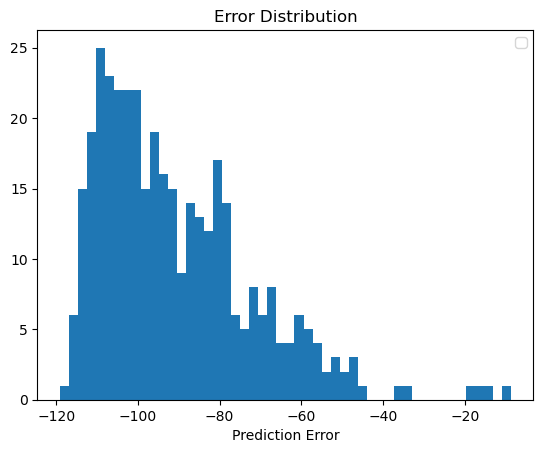

In [42]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

In [43]:
result = permutation_importance(knn_height, X_test, y_test, n_repeats=10)
print(result.importances_mean)

[-8.40424343e-05 -4.88111049e-04]


## TARGET VARIABLE BIA-BIA_TBW

In [44]:
df_TBW = df[['BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW']].copy()

In [45]:
df_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [46]:
df_TBW[df_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


In [47]:
attributes = [col for col in df_TBW.columns if col != 'BIA-BIA_TBW']
X = df_TBW[attributes].values
y = np.array(df_TBW['BIA-BIA_TBW'])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [49]:
knn_TBW = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']}

random_search = RandomizedSearchCV(
    estimator=knn_TBW,
    param_distributions=param_dist,
    n_iter=30,            # number of random combinations
    cv=5,                 # 5-fold cross validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'distance'}
Best score: -0.17185801567874653


In [50]:
knn_TBW  = random_search.best_estimator_
knn_TBW .fit(X_train, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=2, weights='distance')

In [51]:
y_pred = knn_TBW .predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
print('RMSE : %.3f' % mean_squared_error(y_test, y_pred))

R2: 1.000
MSE: 0.106
MAE: 0.172
RMSE : 0.106


Idx | Actual | Predicted | Error
----------------------------------------
  24 | 125.9560 |  122.1406 | 3.8154
 145 | 83.5786 |   85.2983 | 1.7197
  20 | 77.6639 |   78.9980 | 1.3341
 166 | 63.5286 |   62.5820 | 0.9466
 366 | 132.1710 |  131.2421 | 0.9289
 252 | 105.2420 |  104.3285 | 0.9135
 126 | 86.7145 |   85.8376 | 0.8769
 322 | 43.5735 |   42.7371 | 0.8364
  48 | 93.1138 |   93.9074 | 0.7936
 104 | 74.7691 |   74.0830 | 0.6861


C:\Users\ESTER\AppData\Local\Temp\ipykernel_16692\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


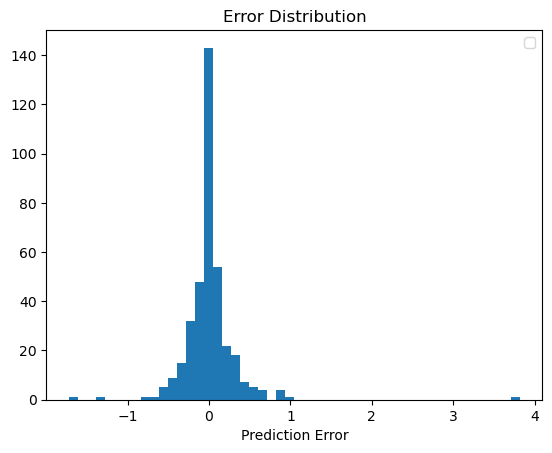

In [52]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

In [53]:
result = permutation_importance(knn_TBW , X_test, y_test, n_repeats=10)
print(result.importances_mean)

[0.55438701 0.51810688]


## TARGET VARIABLE BIA-BIA_Fat

In [ ]:
df_BIA_Fat = df[['Physical-Weight','Physical-Height','BIA-BIA_FMI','BIA-BIA_Fat']].copy()



In [ ]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

In [ ]:
df_BIA_Fat[df_BIA_Fat['BIA-BIA_Fat']==0]

,Physical-Weight,Physical-Height,BIA-BIA_FMI,BIA-BIA_Fat


In [ ]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [79]:
knn_BIA_Fat = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']}

random_search = RandomizedSearchCV(
    estimator=knn_BIA_Fat ,
    param_distributions=param_dist,
    n_iter=30,            # number of random combinations
    cv=5,                 # 5-fold cross validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Best parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best score: -13.886244223700027


In [80]:
knn_BIA_Fat  = random_search.best_estimator_
knn_BIA_Fat .fit(X_train, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

In [81]:
y_pred = knn_BIA_Fat .predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
print('RMSE : %.3f' % mean_squared_error(y_test, y_pred))

R2: 0.967
MSE: 11.877
MAE: 1.975
RMSE : 11.877


In [ ]:
#Overfitting check

train_pred = knn_BIA_Fat .predict(X_train)
y_pred = knn_BIA_Fat .predict(X_test)

print("Train RMSE:", mean_squared_error(y_train, train_pred, squared=False))
print("Test RMSE:", mean_squared_error(y_test, y_pred, squared=False))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))


Train RMSE: 0.0
Test RMSE: 3.446311357393415
Train R2: 1.0
Test R2: 0.9673623127011812


c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Idx | Actual | Predicted | Error
----------------------------------------
 121 | 17.8647 |   38.2380 | 20.3733
  93 | 58.3828 |   78.1838 | 19.8010
 130 | 57.1916 |   75.6305 | 18.4389
  30 | 89.2713 |   71.8332 | 17.4381
   3 |  7.1022 |   21.9255 | 14.8233
  99 | 119.3440 |  105.5070 | 13.8370
 252 | 24.0330 |   36.1994 | 12.1664
 237 | 64.5760 |   52.5562 | 12.0198
 165 | 28.4316 |   38.5876 | 10.1560
 357 | 13.9683 |   23.6990 | 9.7307


C:\Users\ESTER\AppData\Local\Temp\ipykernel_16692\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


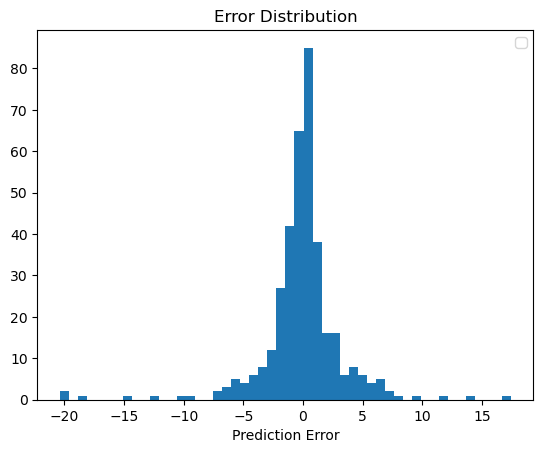

In [ ]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

In [ ]:
result = permutation_importance(knn_BIA_Fat , X_test, y_test, n_repeats=10)
print(result.importances_mean)

[1.92593575 0.11370244 0.15561438]


## TARGET VARIABLE BIA-BIA_DEE

In [93]:
df_BIA_DEE = df[['BIA-BIA_DEE','BIA-BIA_BMR','Basic_Demos-Sex','BIA-BIA_TBW']].copy()

In [94]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE        1
BIA-BIA_BMR        1
Basic_Demos-Sex    0
BIA-BIA_TBW        0
dtype: int64

In [95]:
df_BIA_DEE = df_BIA_DEE.dropna(subset=['BIA-BIA_BMR']) #KNN can not work with null values

In [96]:
df_BIA_DEE[df_BIA_DEE['BIA-BIA_DEE']==0]

,BIA-BIA_DEE,BIA-BIA_BMR,Basic_Demos-Sex,BIA-BIA_TBW


In [97]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [99]:
df_BIA_DEE = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']}

random_search = RandomizedSearchCV(
    estimator=df_BIA_DEE,
    param_distributions=param_dist,
    n_iter=30,            # number of random combinations
    cv=5,                 # 5-fold cross validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 49, 'weights': 'uniform'}
Best score: -94283.63296118056


In [100]:
df_BIA_DEE  = random_search.best_estimator_
df_BIA_DEE .fit(X_train, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=49)

In [101]:
y_pred = df_BIA_DEE .predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
print('RMSE : %.3f' % mean_squared_error(y_test, y_pred))

R2: 0.627
MSE: 107448.313
MAE: 225.039
RMSE : 107448.313


In [102]:
#Overfitting check

train_pred = df_BIA_DEE .predict(X_train)
y_pred = df_BIA_DEE .predict(X_test)

print("Train RMSE:", mean_squared_error(y_train, train_pred, squared=False))
print("Test RMSE:", mean_squared_error(y_test, y_pred, squared=False))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))


Train RMSE: 300.66526983318465
Test RMSE: 327.79309452256723
Train R2: 0.6596300338511427
Test R2: 0.6267684754145177


c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Idx | Actual | Predicted | Error
----------------------------------------
 140 | 4517.1300 | 3071.1069 | 1446.0231
 363 | 4140.3100 | 3008.4406 | 1131.8694
 194 | 3724.5800 | 2657.1859 | 1067.3941
 151 | 3012.9400 | 1967.2784 | 1045.6616
 117 | 3516.1600 | 2486.2239 | 1029.9361
 357 | 3515.6700 | 2493.9165 | 1021.7535
 226 | 2974.7100 | 1999.2059 | 975.5041
 216 | 2963.7700 | 2025.7706 | 937.9994
  63 | 2743.1900 | 1888.8104 | 854.3796
 369 | 2529.3700 | 1699.5063 | 829.8637


C:\Users\ESTER\AppData\Local\Temp\ipykernel_16692\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


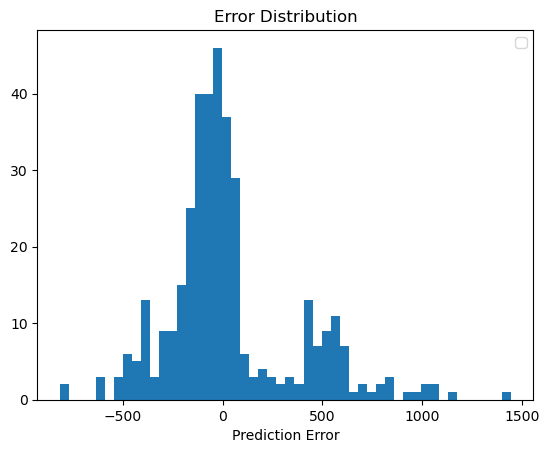

In [103]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

In [104]:
result = permutation_importance(df_BIA_DEE , X_test, y_test, n_repeats=10)
print(result.importances_mean)

[1.19885321e+00 3.38459275e-04 1.25938904e-04]
